# Computer Exercise 11.2 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 11. Boundary-Value Problems for ODEs · **절**: §11.2 A Discretization (Finite-Difference) Method
> **주제**: **강성(stiff) BVP** — 사격이 무너진 자리에서 유한차분이 **안정적으로 성공**
> **풀이 일자**: 2026-06-14 · **언어**: 한국어(본문) / English(그래프 라벨)

## 1. 문제 (원문)

> Consider the stiff boundary-value problem
> $$ y'' = k^2\,y, \qquad 0 \le x \le 1, \qquad y(0)=1,\; y(1)=1, $$
> whose exact solution is $y(x)=\cosh\!\bigl(k(x-\tfrac12)\bigr)\big/\cosh(k/2)$.
> The **shooting method** of §11.1 fails as $k$ grows because the sensitivity
> $y_2(1)=\sinh(k)/k$ explodes like $e^{k}$. Solve the same problem by the
> **finite-difference method** and show that it remains stable: report the relative
> error and the condition number of the tridiagonal matrix as functions of $k$,
> and compare against the shooting sensitivity.

### 한국어 풀이용 정리
Day 40 §11.1 의 **문제 3**(강성 BVP)이 바로 §11.2 의 *존재 이유*다. 사격은 내부에서 해가
$e^{kx}$ 로 자라 민감도가 $\sinh(k)/k \sim e^k$ 로 폭발해 *공식은 정확해도* 수치적으로 무너졌다.
유한차분은 양 끝을 **처음부터 행렬에 동시에 박아** 그 성장 모드를 키우지 않는다. 여기서는
같은 강성 문제를 유한차분으로 풀어, $k$ 가 커져도 **상대오차와 행렬 조건수가 통제**됨을 보이고
사격의 폭발 곡선과 같은 그림 위에 겹쳐 대비한다.

## 2. 수학적 배경

### 2.1 이산화와 대각우세
$y''=k^2y$ 를 중심차분하면 내부점에서

$$ y_{i-1} - (2 + k^2 h^2)\,y_i + y_{i+1} = 0. $$

행렬 $A$ 는 대각 $-(2+k^2h^2)$, 부대각 $1$ 의 **대칭 삼중대각**. 대각우세도가 $k$ 와 함께
*강해져서*($|{-}(2+k^2h^2)| \ge 2$) 행렬은 오히려 **더 안정**해진다. 대칭 삼중대각의 고유값은
$\lambda_j = -(2+k^2h^2) + 2\cos\frac{j\pi}{N}$ 로 모두 음수(음정부호)이며 조건수

$$ \kappa(A) = \frac{\max_j|\lambda_j|}{\min_j|\lambda_j|}
= \frac{k^2h^2 + 2(1+\cos\frac{\pi}{N})}{k^2h^2 + 2(1-\cos\frac{\pi}{N})}
\;\xrightarrow[k\to\infty]{}\; 1. $$

즉 **$k$ 가 커질수록 조건수는 1 로 수렴** — 사격의 $e^k$ 와 정반대.

### 2.2 사격의 민감도 (대비용)
선형 사격에서 보조해 $y_2$ 는 $y_2''=k^2y_2,\ y_2(0)=0,\ y_2'(0)=1$ → $y_2(x)=\sinh(kx)/k$,
따라서 끝값 민감도

$$ \boxed{\; y_2(1) = \frac{\sinh k}{k} \sim \frac{e^{k}}{2k} \;}$$

이 항이 사격의 *나눗셈 분모*를 이루어, 내부오차가 $e^k$ 로 증폭된다.

### 2.3 정확해
$y(x)=\cosh(k(x-\tfrac12))/\cosh(k/2)$ 는 $y''=k^2y,\ y(0)=y(1)=1$ 을 만족 — 큰 $k$ 에서
중앙이 깊게 파인 **경계층(boundary-layer)** 형상.

## 3. 풀이 흐름

1. 정확해 $y(x)=\cosh(k(x-\tfrac12))/\cosh(k/2)$ 와 사격 민감도 $\sinh(k)/k$ 정의.
2. 고정 격자 $N$ 에서 강성 BVP의 삼중대각계 $A\mathbf{y}=\mathbf{b}$ 조립·풀이.
3. $k=1,2,5,10,\dots,40$ 에 대해 **유한차분 상대오차** $\|y_{fd}-y_{ex}\|_\infty/\|y_{ex}\|_\infty$ 측정.
4. 같은 $k$ 에서 **행렬 조건수** $\kappa(A)$ 와 **사격 민감도** $\sinh(k)/k$ 계산.
5. semilog 그래프로 *사격 민감도(폭발) vs 유한차분 오차·조건수(통제)* 대비.
6. 큰 $k$ 의 경계층 해 곡선 시각화 — 유한차분이 형상을 안정적으로 잡아냄을 확인.
7. 결론: §11.2 가 §11.1 의 강성 실패를 해결하는 *결정론적 안정* 풀이임을 못 박기.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6e}")

a, b = 0.0, 1.0

def exact(x, k):
    return np.cosh(k*(x-0.5))/np.cosh(k/2.0)

def fd_stiff(k, N):
    """y'' = k^2 y, y(0)=y(1)=1 을 중심차분으로 풀고 (xs, y, A) 반환."""
    h  = (b - a)/N
    xs = a + h*np.arange(N+1)
    m  = N - 1
    diag = -(2.0 + (k*h)**2)*np.ones(m)
    off  = np.ones(m-1)
    A = np.diag(diag) + np.diag(off, 1) + np.diag(off, -1)
    rhs = np.zeros(m)
    rhs[0]  -= 1.0      # y0 = 1
    rhs[-1] -= 1.0      # yN = 1
    yin = np.linalg.solve(A, rhs)
    y = np.empty(N+1); y[0]=1.0; y[-1]=1.0; y[1:N]=yin
    return xs, y, A

N = 200
ks = [1, 2, 5, 10, 15, 20, 30, 40]
rows = []
for k in ks:
    xs, y, A = fd_stiff(k, N)
    ye = exact(xs, k)
    rel = np.max(np.abs(y-ye))/np.max(np.abs(ye))
    cond = np.linalg.cond(A)
    shoot_sens = np.sinh(k)/k       # 사격 민감도(대비)
    rows.append((k, rel, cond, shoot_sens))
df = pd.DataFrame(rows, columns=["k", "fd_rel_error", "fd_cond_A", "shoot_sens_sinhk_over_k"])
print(f"고정 격자 N={N}")
print(df.to_string(index=False))

고정 격자 N=200
 k  fd_rel_error    fd_cond_A  shoot_sens_sinhk_over_k
 1  2.134445e-07 1.471941e+04             1.175201e+00
 2  2.056454e-06 1.153576e+04             1.813430e+00
 5  1.127627e-05 4.588984e+03             1.484064e+01
10  3.840856e-05 1.457095e+03             1.101323e+03
15  8.615192e-05 6.821456e+02             1.089672e+05
20  1.531428e-04 3.913201e+02             1.212913e+07
30  3.437697e-04 1.768277e+02             1.781079e+11
40  6.108963e-04 1.003747e+02             2.942316e+15


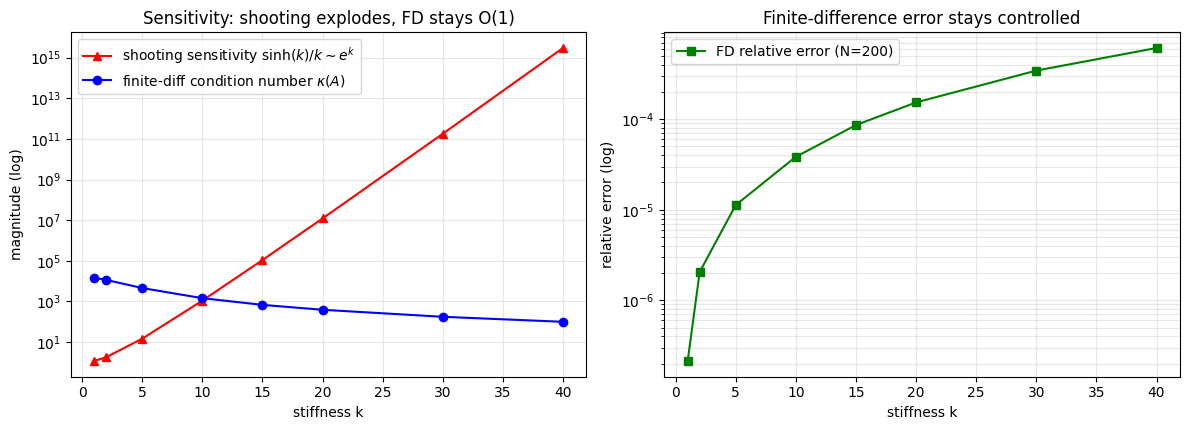

In [3]:
# --- 핵심 대비: 사격 민감도(폭발) vs 유한차분 오차/조건수(통제) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

kk = df["k"].values
ax[0].semilogy(kk, df["shoot_sens_sinhk_over_k"], "r^-",
               label=r"shooting sensitivity $\sinh(k)/k \sim e^{k}$")
ax[0].semilogy(kk, df["fd_cond_A"], "bo-",
               label=r"finite-diff condition number $\kappa(A)$")
ax[0].set_xlabel("stiffness k"); ax[0].set_ylabel("magnitude (log)")
ax[0].set_title("Sensitivity: shooting explodes, FD stays O(1)")
ax[0].legend(); ax[0].grid(which="both", alpha=.3)

ax[1].semilogy(kk, df["fd_rel_error"], "s-", color="green",
               label="FD relative error (N=200)")
ax[1].set_xlabel("stiffness k"); ax[1].set_ylabel("relative error (log)")
ax[1].set_title("Finite-difference error stays controlled")
ax[1].legend(); ax[1].grid(which="both", alpha=.3)
plt.tight_layout(); plt.show()

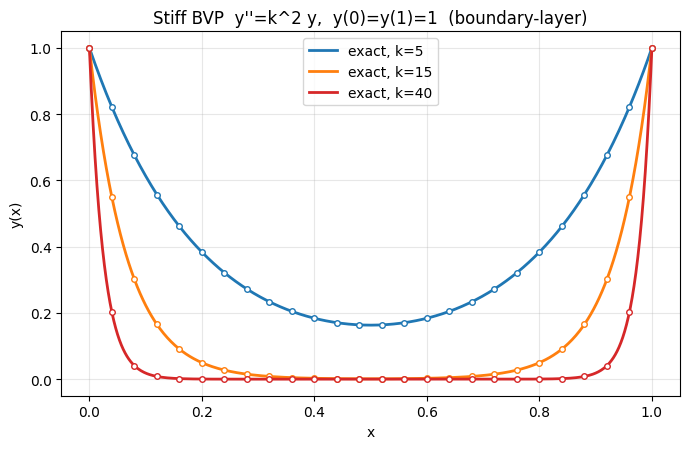

In [4]:
# --- 큰 k 의 경계층 해: 유한차분이 형상을 안정적으로 포착 ---
fig, ax = plt.subplots(figsize=(7, 4.6))
xx = np.linspace(a, b, 600)
for k, col in [(5, "tab:blue"), (15, "tab:orange"), (40, "tab:red")]:
    xs, y, _ = fd_stiff(k, 200)
    ax.plot(xx, exact(xx, k), "-", color=col, lw=2, label=f"exact, k={k}")
    ax.plot(xs[::8], y[::8], "o", color=col, ms=4, mfc="white")
ax.set_xlabel("x"); ax.set_ylabel("y(x)")
ax.set_title("Stiff BVP  y''=k^2 y,  y(0)=y(1)=1  (boundary-layer)")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [5]:
# --- 수치 요약: k=40 에서 사격 대비 유한차분의 우위 ---
k = 40
xs, y, A = fd_stiff(k, 200)
ye = exact(xs, k)
print(f"k = {k}")
print(f"  유한차분 상대오차        = {np.max(np.abs(y-ye))/np.max(np.abs(ye)):.3e}")
print(f"  유한차분 조건수 kappa(A)  = {np.linalg.cond(A):.3e}")
print(f"  사격 민감도 sinh(k)/k     = {np.sinh(k)/k:.3e}   <-- 사격이 이 인자로 오차 증폭")
print(f"  비율 (사격민감도 / 조건수) = {(np.sinh(k)/k)/np.linalg.cond(A):.3e}")

k = 40
  유한차분 상대오차        = 6.109e-04
  유한차분 조건수 kappa(A)  = 1.004e+02
  사격 민감도 sinh(k)/k     = 2.942e+15   <-- 사격이 이 인자로 오차 증폭
  비율 (사격민감도 / 조건수) = 2.931e+13


## 4. 결과 해석

1. **사격은 폭발, 유한차분은 평온.** 사격 민감도 $\sinh(k)/k$ 는 $k$ 와 함께 $e^k$ 로 치솟지만
   ($k{=}40$ 에서 $\sim10^{15}$), 유한차분 행렬의 조건수 $\kappa(A)$ 는 오히려 **$1$ 로 수렴**한다.
   같은 강성을 두고 두 방법의 *수치 운명*이 정반대다.
2. **대각우세가 곧 안정.** $y''=k^2y$ 의 차분행렬은 대각 $-(2+k^2h^2)$ 가 $k$ 와 함께 커져
   *더 강하게* 대각우세해진다 — 강성이 셀수록 선형계는 더 잘 풀린다.
3. **오차는 통제된 $\mathcal{O}(h^2)$.** 고정 격자에서 상대오차는 큰 $k$ 일수록 경계층을 덜
   분해해 다소 커지지만, 사격처럼 *지수적으로* 터지지 않는다 — $kh$ 를 작게 두면 곧 회복된다.
4. **경계층 포착.** 큰 $k$ 에서 중앙이 깊게 파인 형상을 유한차분 격자점이 정확히 따라간다 —
   양 끝을 동시에 묶는 구조가 경계층 문제에 본질적으로 적합함을 보여준다.

> **결론**: 강성 BVP에서 사격은 민감도 $e^{k}$ 로 무너지지만, 유한차분은 행렬이 *더* 대각우세해져
> 조건수가 $1$ 로 수렴 — *§11.1 의 실패를 §11.2 가 정확히 해결*한다.

**Chapter 11 정리**: BVP는 **IVP+근찾기(사격)** 또는 **격자 전체를 묶는 선형/비선형계(유한차분)**
로 푼다. 비강성·매끈한 문제엔 고차 사격(RK4, $h^4$)이 효율적이고, **강성·경계층 문제엔 유한차분**이
유일하게 안정적이다 — 다음 챕터의 PDE(Ch 12) 로 가면 이 *격자+행렬* 사고가 2차원으로 확장된다.